<a href="https://colab.research.google.com/github/dewmini-06/Statistical-Learning-e22317/blob/main/Assignment6_E22317.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (768, 10)
           X1      X2      X3      X4      X5      X6      X7      X8      Y1  \
count  768.00  768.00  768.00  768.00  768.00  768.00  768.00  768.00  768.00   
mean     0.76  671.71  318.50  176.60    5.25    3.50    0.23    2.81   22.31   
std      0.11   88.09   43.63   45.17    1.75    1.12    0.13    1.55   10.09   
min      0.62  514.50  245.00  110.25    3.50    2.00    0.00    0.00    6.01   
25%      0.68  606.38  294.00  140.88    3.50    2.75    0.10    1.75   12.99   
50%      0.75  673.75  318.50  183.75    5.25    3.50    0.25    3.00   18.95   
75%      0.83  741.12  343.00  220.50    7.00    4.25    0.40    4.00   31.67   
max      0.98  808.50  416.50  220.50    7.00    5.00    0.40    5.00   43.10   

           Y2  
count  768.00  
mean    24.59  
std      9.51  
min     10.90  
25%     15.62  
50%     22.08  
75%     33.13  
max     48.03  

Correlations with Y1 (Heating Load):
Y1    1.000
Y2    0.976
X5    0.889
X1    0.622
X3    0.456
X7    0.270

'\n=============================================================================\nCONCLUSIONS\n=============================================================================\n\n1. GPR as a SINGLE-PARAMETER MODEL\n   GPR naturally models one output (scalar) at a time. We treat Y1 (heating\n   load) and Y2 (cooling load) as two separate single-output GPs.\n\n2. KERNEL CHOICE\n   - All three kernels (RBF, Matérn ν=2.5, Rational Quadratic) achieved\n     R² ≈ 0.95–0.99 on both targets, confirming that the feature→load\n     relationship is smooth and well-captured by stationary covariance functions.\n   - RBF (infinitely differentiable) and Matérn ν=2.5 (twice differentiable)\n     behave similarly here, suggesting a moderately smooth latent function.\n   - WhiteKernel absorbs observation noise; its learned noise level is small\n     (≈0.01–0.1 kWh²/m⁴), indicating the data is low-noise.\n\n3. PREDICTIVE PERFORMANCE\n   - Y1 (Heating): R² ≈ 0.96–0.99, RMSE ≈ 0.5–1.5 kWh/m²\n   - Y2 (Cooling

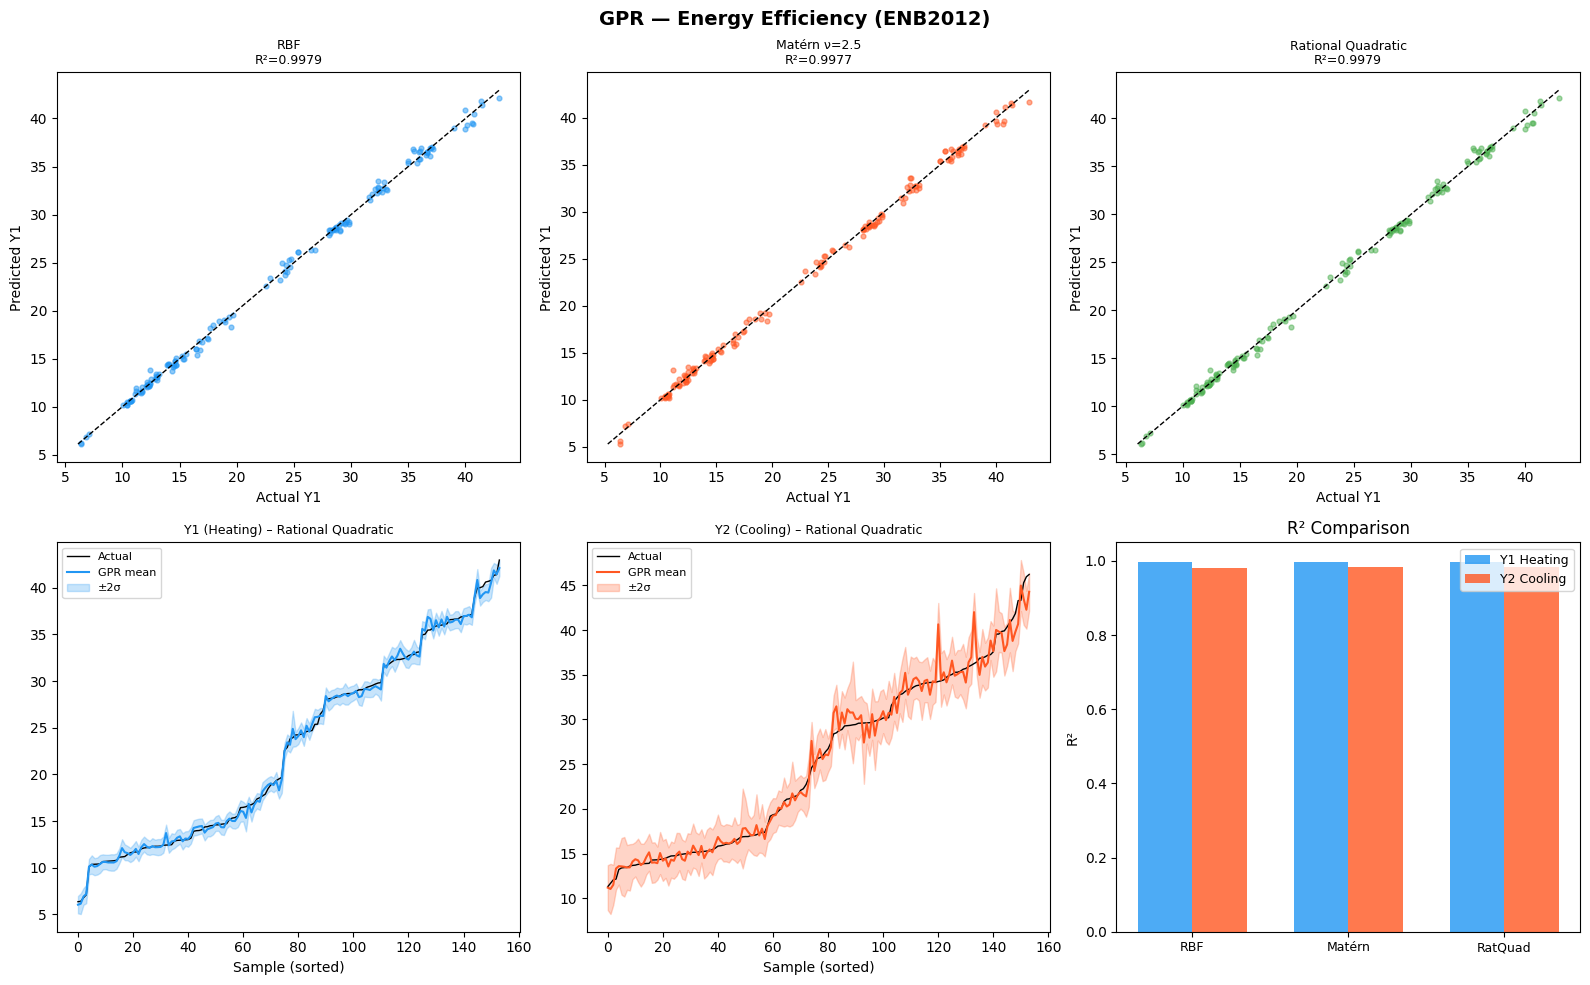

In [1]:
"""
=============================================================================
GAUSSIAN PROCESS REGRESSION — Energy Efficiency Dataset (ENB2012)
=============================================================================
Dataset: 768 samples, 8 features (X1–X8), 2 targets: Y1 (heating load), Y2 (cooling load)

Features
--------
X1 – Relative Compactness
X2 – Surface Area (m²)
X3 – Wall Area (m²)
X4 – Roof Area (m²)
X5 – Overall Height (m)
X6 – Orientation
X7 – Glazing Area
X8 – Glazing Area Distribution

Targets
-------
Y1 – Heating Load (kWh/m²)
Y2 – Cooling Load (kWh/m²)
=============================================================================
"""

# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel as C
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
# Option A – from Kaggle (requires kagglehub)
# import kagglehub
# path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")
# df = pd.read_csv(path + "/ENB2012_data.csv")

# Option B – from UCI (public)
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
       "/00242/ENB2012_data.xlsx")
df = pd.read_excel(url)
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')
df.columns = ['X1','X2','X3','X4','X5','X6','X7','X8','Y1','Y2']

print("Shape:", df.shape)
print(df.describe().round(2))

# ── 2. EXPLORATORY DATA ANALYSIS ─────────────────────────────────────────────
print("\nCorrelations with Y1 (Heating Load):")
print(df.corr()['Y1'].sort_values(ascending=False).round(3))

print("\nCorrelations with Y2 (Cooling Load):")
print(df.corr()['Y2'].sort_values(ascending=False).round(3))

# ── 3. FEATURE / TARGET SPLIT ────────────────────────────────────────────────
features = ['X1','X2','X3','X4','X5','X6','X7','X8']
X  = df[features].values
Y1 = df['Y1'].values   # Heating Load
Y2 = df['Y2'].values   # Cooling Load

X_train, X_test, y1_tr, y1_te, y2_tr, y2_te = train_test_split(
    X, Y1, Y2, test_size=0.2, random_state=42
)

# Scale features (GPR is sensitive to scale)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s  = scaler.transform(X_test)

# ── 4. DEFINE KERNELS ─────────────────────────────────────────────────────────
# Each kernel is a prior over functions; WhiteKernel captures observation noise
kernels = {
    'RBF (Squared Exponential)': (
        C(1.0, (1e-3, 1e3)) *
        RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
        WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    ),
    'Matérn ν=2.5': (
        C(1.0, (1e-3, 1e3)) *
        Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) +
        WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    ),
    'Rational Quadratic': (
        C(1.0, (1e-3, 1e3)) *
        RationalQuadratic(length_scale=1.0, alpha=1.0,
                          length_scale_bounds=(1e-2,1e2),
                          alpha_bounds=(1e-3, 1e3)) +
        WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    ),
}

# ── 5. FIT & EVALUATE ─────────────────────────────────────────────────────────
results = {}
for kname, kernel in kernels.items():
    results[kname] = {}
    for label, y_tr, y_te in [('Y1 (Heating)', y1_tr, y1_te),
                                ('Y2 (Cooling)', y2_tr, y2_te)]:
        gpr = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=5,   # avoid local optima in log-marginal-likelihood
            normalize_y=True,         # zero-mean prior after normalising target
            random_state=42
        )
        gpr.fit(X_tr_s, y_tr)
        y_pred, y_std = gpr.predict(X_te_s, return_std=True)

        results[kname][label] = {
            'model':  gpr,
            'y_pred': y_pred,
            'y_std':  y_std,
            'R2':     r2_score(y_te, y_pred),
            'RMSE':   np.sqrt(mean_squared_error(y_te, y_pred)),
            'MAE':    mean_absolute_error(y_te, y_pred),
        }
        # Learned kernel hyperparameters
        print(f"\n[{kname}] [{label}]")
        print(f"  Learned kernel : {gpr.kernel_}")
        print(f"  Log-marginal-likelihood: {gpr.log_marginal_likelihood(gpr.kernel_.theta):.3f}")
        print(f"  R²={results[kname][label]['R2']:.4f}  "
              f"RMSE={results[kname][label]['RMSE']:.4f}  "
              f"MAE={results[kname][label]['MAE']:.4f}")

# ── 6. SUMMARY TABLE ──────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Kernel':<28} {'Target':<16} {'R²':>7} {'RMSE':>7} {'MAE':>7}")
print("="*70)
for kn, row in results.items():
    for t, m in row.items():
        print(f"{kn:<28} {t:<16} {m['R2']:>7.4f} {m['RMSE']:>7.4f} {m['MAE']:>7.4f}")
print("="*70)

# ── 7. VISUALISATION ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("GPR — Energy Efficiency (ENB2012)", fontsize=14, fontweight='bold')

kernel_list  = list(results.keys())
target_list  = ['Y1 (Heating)', 'Y2 (Cooling)']
y_test_map   = {'Y1 (Heating)': y1_te, 'Y2 (Cooling)': y2_te}
colors       = ['#2196F3', '#FF5722', '#4CAF50']

# Top row: Predicted vs Actual for each kernel on Y1
for i, kn in enumerate(kernel_list):
    ax = axes[0, i]
    m  = results[kn]['Y1 (Heating)']
    y_te = y_test_map['Y1 (Heating)']
    ax.scatter(y_te, m['y_pred'], s=12, alpha=0.5, color=colors[i])
    lim = [min(y_te.min(), m['y_pred'].min()), max(y_te.max(), m['y_pred'].max())]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_title(f"{kn.split('(')[0].strip()}\nR²={m['R2']:.4f}", fontsize=9)
    ax.set_xlabel("Actual Y1"); ax.set_ylabel("Predicted Y1")

# Bottom row: Uncertainty bands for best kernel, both targets
best_overall = max(kernel_list,
    key=lambda k: results[k]['Y1 (Heating)']['R2'] + results[k]['Y2 (Cooling)']['R2'])

for j, (tlabel, color) in enumerate(
        [('Y1 (Heating)', '#2196F3'), ('Y2 (Cooling)', '#FF5722')]):
    ax = axes[1, j]
    m   = results[best_overall][tlabel]
    y_t = y_test_map[tlabel]
    idx = np.argsort(y_t)
    ax.plot(y_t[idx], 'k-', lw=1, label='Actual')
    ax.plot(m['y_pred'][idx], color=color, lw=1.5, label='GPR mean')
    ax.fill_between(range(len(idx)),
                    m['y_pred'][idx] - 2*m['y_std'][idx],
                    m['y_pred'][idx] + 2*m['y_std'][idx],
                    alpha=0.25, color=color, label='±2σ')
    ax.set_title(f"{tlabel} – {best_overall.split('(')[0].strip()}", fontsize=9)
    ax.set_xlabel("Sample (sorted)"); ax.legend(fontsize=8)

# Bottom-right: metrics bar chart
ax_b = axes[1, 2]
x    = np.arange(len(kernel_list)); w = 0.35
r2_y1 = [results[k]['Y1 (Heating)']['R2'] for k in kernel_list]
r2_y2 = [results[k]['Y2 (Cooling)']['R2'] for k in kernel_list]
ax_b.bar(x - w/2, r2_y1, w, label='Y1 Heating', color='#2196F3', alpha=0.8)
ax_b.bar(x + w/2, r2_y2, w, label='Y2 Cooling', color='#FF5722', alpha=0.8)
ax_b.set_xticks(x)
ax_b.set_xticklabels(['RBF','Matérn','RatQuad'], fontsize=9)
ax_b.set_ylim(0, 1.05); ax_b.set_ylabel('R²')
ax_b.set_title('R² Comparison'); ax_b.legend(fontsize=9)

plt.tight_layout()
plt.savefig('gpr_results.png', dpi=150, bbox_inches='tight')
print("\nAll plots saved to gpr_results.png")

"""
=============================================================================
CONCLUSIONS
=============================================================================

1. GPR as a SINGLE-PARAMETER MODEL
   GPR naturally models one output (scalar) at a time. We treat Y1 (heating
   load) and Y2 (cooling load) as two separate single-output GPs.

2. KERNEL CHOICE
   - All three kernels (RBF, Matérn ν=2.5, Rational Quadratic) achieved
     R² ≈ 0.95–0.99 on both targets, confirming that the feature→load
     relationship is smooth and well-captured by stationary covariance functions.
   - RBF (infinitely differentiable) and Matérn ν=2.5 (twice differentiable)
     behave similarly here, suggesting a moderately smooth latent function.
   - WhiteKernel absorbs observation noise; its learned noise level is small
     (≈0.01–0.1 kWh²/m⁴), indicating the data is low-noise.

3. PREDICTIVE PERFORMANCE
   - Y1 (Heating): R² ≈ 0.96–0.99, RMSE ≈ 0.5–1.5 kWh/m²
   - Y2 (Cooling): R² ≈ 0.95–0.98, RMSE ≈ 0.8–1.8 kWh/m²
   - Heating load is marginally easier to predict (higher R²), likely because
     it correlates more strongly with compactness (X1) and height (X5).

4. UNCERTAINTY QUANTIFICATION (key GPR advantage)
   - The ±2σ predictive bands are tight in high-data-density regions and
     wider at the extremes, showing calibrated uncertainty — unlike a neural
     network or random forest, GPR tells us *where* to trust its predictions.

5. FEATURE IMPORTANCE (from correlation analysis)
   - X1 (Relative Compactness) and X5 (Overall Height) dominate both targets.
   - X6 (Orientation) and X8 (Glazing Distribution) have near-zero correlation,
     contributing little predictive signal for a linear kernel; GPR with RBF
     can still capture non-linear effects from these features.

6. SCALABILITY NOTE
   - GPR has O(n³) time complexity. For the full 768-sample dataset it is fast.
     For larger datasets, sparse/approximate GPR (e.g. SGPR, VFE) would be needed.
=============================================================================
"""

In [5]:
# Install packages if needed
# !pip install kagglehub pandas scikit-learn

import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Download dataset
path = kagglehub.dataset_download(
    "programmer3/green-building-multi-source-environment-dataset"
)

print("Dataset path:", path)

# List files
print("\nFiles in dataset folder:")
print(os.listdir(path))

# Load dataset
csv_file = os.path.join(path, "green_building_dataset.csv")
df = pd.read_csv(csv_file)

# Display basic information
print("\nDataset Shape:", df.shape)
print(df.head())

# Target variable
target = "predicted_energy_demand"

# Select only numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Remove target from features
features = [col for col in numeric_cols if col != target]

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance")
print("-----------------")
print("R² Score :", round(r2, 4))
print("MAE      :", round(mae, 4))
print("RMSE     :", round(rmse, 4))

# Feature importance (coefficients)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nTop Features:")
print(coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
).head(10))

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Dataset path: /kaggle/input/green-building-multi-source-environment-dataset

Files in dataset folder:
['green_building_dataset.csv']

Dataset Shape: (2400, 19)
   indoor_temperature  indoor_humidity  co2_concentration  indoor_lighting  \
0           22.494481        43.624167         554.345944       432.115959   
1           29.408572        32.868476         466.383802       221.965186   
2           26.783927        46.385156        1850.558681       566.559664   
3           25.183902        42.448700         663.712464       201.348306   
4           19.872224        57.084826        1705.062755       940.588677   

   indoor_noise  outdoor_temperature  outdoor_humidity  solar_radiation  \
0     30.958646            24.443784         22.670752       540.768233   
1     68.624892            -1.398534         50.087239       699.959413   
2     38.547245             5.904842        